In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.optimizers import SGD
from concurrent.futures import ThreadPoolExecutor

In [2]:
# 1. Thread Configuration for Concurrency
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
print("Environment set. TF restricted to 1 thread per instance to allow concurrency.")

Environment set. TF restricted to 1 thread per instance to allow concurrency.


In [3]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [4]:
def iid_partition(x, y, num_clients):
    idx = np.random.permutation(len(x))
    x_shuffled, y_shuffled = x[idx], y[idx]
    x_parts = np.array_split(x_shuffled, num_clients)
    y_parts = np.array_split(y_shuffled, num_clients)
    partitions = list(zip(x_parts, y_parts))
    return partitions

In [5]:
def non_iid_partition(x, y, num_clients):
    sorted_idx = np.argsort(y)
    X_sorted, Y_sorted = x[sorted_idx], y[sorted_idx]
    num_shards = 2 * num_clients
    size_shards = len(x) // num_shards
    shards_idx = np.random.permutation(num_shards)
    partitions = []
    for i in range(num_clients):
        s1, s2 = shards_idx[2*i], shards_idx[2*i+1]
        X_client = np.concatenate((X_sorted[s1*size_shards:(s1+1)*size_shards], X_sorted[s2*size_shards:(s2+1)*size_shards]), axis=0)
        Y_client = np.concatenate((Y_sorted[s1*size_shards:(s1+1)*size_shards], Y_sorted[s2*size_shards:(s2+1)*size_shards]), axis=0)
        idx = np.random.permutation(len(X_client))
        partitions.append((X_client[idx], Y_client[idx]))
    return partitions

In [6]:
# 4. Model Generation
def cnn_model():
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(32, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax'),
    ])
    model.compile(optimizer=SGD(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
def local_training(client_data, global_weights, mu):
    X_local, Y_local = client_data
    num_sample = len(X_local)
    model = cnn_model()
    model.set_weights(global_weights)
    optimizer = SGD(learning_rate=0.01)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
    global_weights_tensors = [tf.constant(w) for w in global_weights]
    dataset = tf.data.Dataset.from_tensor_slices((X_local, Y_local)).batch(32)
    
    def train_step(x, y):
        with tf.GradientTape() as tape:
            y_pred = model(x, training=True)
            base_loss = loss_fn(y, y_pred)
            
            proximal_term = 0.0
            for local_var, global_var in zip(model.trainable_variables, global_weights_tensors):
                proximal_term += tf.reduce_sum(tf.square(local_var - global_var))
                
            total_loss = base_loss + (mu / 2.0) * proximal_term    
        grads = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    for epoch in range(2):
        for batch_x, batch_y in dataset:
            train_step(batch_x, batch_y)
            
    return model.get_weights(), num_sample
               

In [8]:
def aggregate_weights(client_updates, global_weights):
    tot_sample = sum(num_samples for _, num_samples in client_updates)
    new_weights = [np.zeros_like(w) for w in global_weights]
    
    for local_weights, num_samples in client_updates:
        w_factor = num_samples / tot_sample
        for i in range(len(new_weights)):
            new_weights[i] += local_weights[i] * w_factor
            
    return new_weights

In [9]:
def evaluate_global(global_model, X_test, Y_test):
    loss, accuracy = global_model.evaluate(X_test, Y_test, verbose=1)
    return loss, accuracy

In [10]:
def run_simulation(partitions, X_test, Y_test, num_clients, rounds, participation_rate, mu):
    global_model = cnn_model()
    global_weights = global_model.get_weights()
    max_workers = min(num_clients, 12)
    history = []
    
    for r in range(1, rounds + 1):
        num_active = max(1, int(num_clients * participation_rate))
        active_clients = random.sample(range(num_clients), num_active)
        client_updates = []
        
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [executor.submit(local_training, partitions[i], global_weights, mu) for i in active_clients]
            for future in futures:
                client_updates.append(future.result())
                
        # Aggregate and Update
        global_weights = aggregate_weights(client_updates, global_weights)
        global_model.set_weights(global_weights)
        
        # Evaluate
        loss, acc = evaluate_global(global_model, X_test, Y_test)
        history.append({'round': r, 'loss': loss, 'acc': acc})
        print(f"Round {r} | Accuracy: {acc} | Loss: {loss}")
        
    return history

In [11]:
CLIENTS=10
ROUNDS=20
PARTICIPATION_RATE =1
MU=0.1
    
print(f"=== RUNNING IID FEDPROX ({CLIENTS} Clients, {PARTICIPATION_RATE*100}% Participation) ===")
iid_parts = iid_partition(X_train, Y_train, CLIENTS)
iid_history = run_simulation(iid_parts, X_test, Y_test, CLIENTS, ROUNDS, PARTICIPATION_RATE, MU)
    
print(f"\n=== RUNNING NON-IID FEDPROX ({CLIENTS} Clients, {PARTICIPATION_RATE*100}% Participation) ===")
non_iid_parts = non_iid_partition(X_train, Y_train, CLIENTS)
non_iid_history = run_simulation(non_iid_parts, X_test, Y_test, CLIENTS, ROUNDS, PARTICIPATION_RATE, MU)

=== RUNNING IID FEDPROX (10 Clients, 100% Participation) ===
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8574 - loss: 0.5293
Round 1 | Accuracy: 0.8574000000953674 | Loss: 0.5292553305625916
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9161 - loss: 0.2991
Round 2 | Accuracy: 0.916100025177002 | Loss: 0.29914677143096924
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9352 - loss: 0.2281
Round 3 | Accuracy: 0.9351999759674072 | Loss: 0.2281060516834259
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9459 - loss: 0.1875
Round 4 | Accuracy: 0.945900022983551 | Loss: 0.1874927580356598
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9540 - loss: 0.1592
Round 5 | Accuracy: 0.9539999961853027 | Loss: 0.15918265283107758
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9621 - loss: 0.1387
Round 6 | Accuracy: 0.9621000289916992 | Loss: 0.13868652284145355
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9647 - loss: 0.1231
Round 7 | 

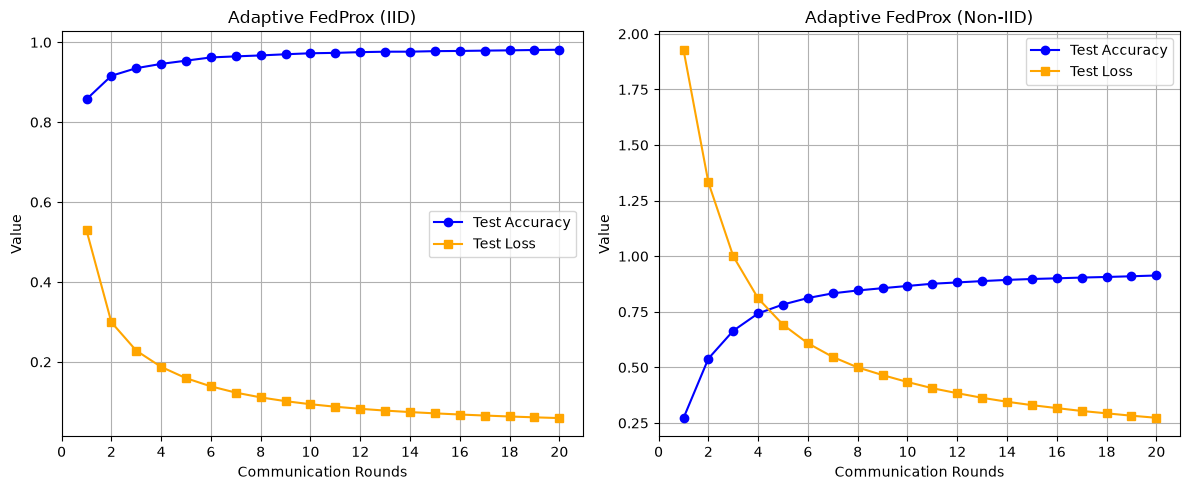

In [12]:
iid_df = pd.DataFrame(iid_history)
non_iid_df = pd.DataFrame(non_iid_history)
    
plt.figure(figsize=(12, 5))
    
plt.subplot(1, 2, 1)
plt.plot(iid_df['round'], iid_df['acc'], marker='o', color='blue', label='Test Accuracy')
plt.plot(iid_df['round'], iid_df['loss'], marker='s', color='orange', label='Test Loss')
plt.title("Adaptive FedProx (IID)")
plt.xlabel("Communication Rounds")
plt.ylabel("Value")
plt.xticks(range(0, ROUNDS + 1, 2))
plt.legend()
plt.grid(True)
    
plt.subplot(1, 2, 2)
plt.plot(non_iid_df['round'], non_iid_df['acc'], marker='o', color='blue', label='Test Accuracy')
plt.plot(non_iid_df['round'], non_iid_df['loss'], marker='s', color='orange', label='Test Loss')
plt.title("Adaptive FedProx (Non-IID)")
plt.xlabel("Communication Rounds")
plt.ylabel("Value")
plt.xticks(range(0, ROUNDS + 1, 2))
plt.legend()
plt.grid(True)
    
plt.tight_layout()
plt.show()